In [2]:
from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive/faster_rcnn
%cp VOC2007.zip /content
%cp VOC2012.zip /content
%cd /content

drive.flush_and_unmount()

Mounted at /content/drive
/content/drive/MyDrive/faster_rcnn
/content


In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from src.backbone import backbone_transform

transform = backbone_transform
transform

In [3]:
from src.dataset import get_voc_img_paths_train, get_voc_img_paths_test, create_voc_dataloader

voc2007_img_paths_train, voc2012_img_paths_train = get_voc_img_paths_train()
voc2007_img_paths_test, voc2012_img_paths_test = get_voc_img_paths_test()

train_dataloader = create_voc_dataloader(img_paths_list=voc2007_img_paths_train, transform=transform, batch_size=32, shuffle=True)
dataset = train_dataloader.dataset

In [10]:
img, gt_boxes, gt_labels, img_sizes_before_pad = next(iter(train_dataloader))
img.shape, gt_boxes[0], gt_labels[0], img_sizes_before_pad[0]

(torch.Size([32, 3, 900, 1000]),
 tensor([[0.5947, 0.5820, 0.6480, 0.6760],
         [0.3013, 0.2660, 0.6053, 0.6800]]),
 tensor([ 4, 14]),
 (600, 800))

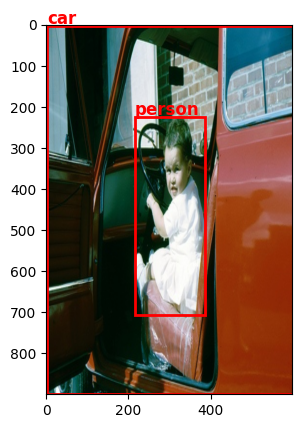

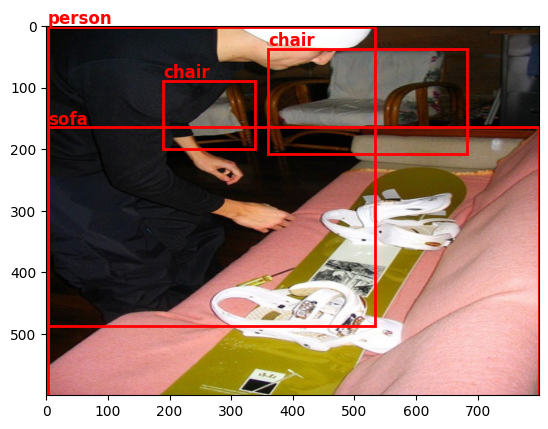

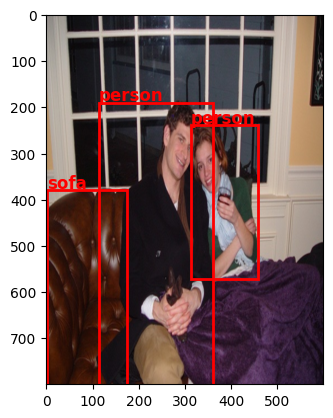

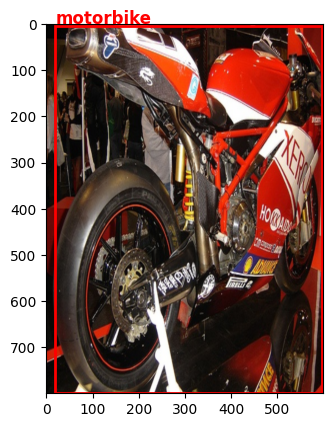

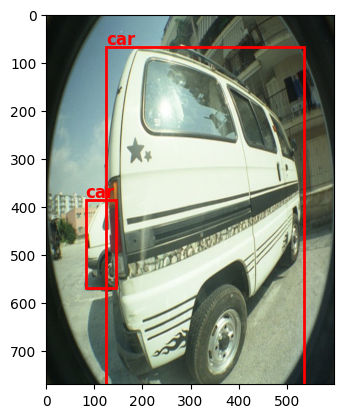

In [6]:
from src.utils import display_random_images_with_annotations, plot_image_with_annotations

display_random_images_with_annotations(dataset)

In [18]:
from src.backbone import Backbone
import torch

backbone = Backbone()
backbone.eval()  # Set the backbone to evaluation mode

backbone.to(device)  # Move the backbone to the appropriate device
img = img.to(device)
with torch.inference_mode():
    output = backbone(img)
    print(f"Backbone output shape: {output.shape}")
    

KeyboardInterrupt: 

In [9]:
import torch
scales = torch.tensor([128, 256, 512])
ratios = torch.tensor([0.5, 1, 2])

widths = scales.view(-1, 1) * torch.sqrt(ratios).view(1, -1)
heights = scales.view(-1, 1) / torch.sqrt(ratios).view(1, -1)

widths.shape, heights.shape, torch.stack((widths.flatten(), heights.flatten()), dim=-1)[None, None, : ].shape  # This will give you the width and height pairs for each scale and ratio combination

(torch.Size([3, 3]), torch.Size([3, 3]), torch.Size([1, 1, 9, 2]))

In [12]:
import torch
import torch.nn as nn

class RPN_Head(nn.Module):
    def __init__(self, in_channels, mid_channels):
        super(RPN_Head, self).__init__()
        self.num_anchors = 9
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1)
        self.conv_cls = nn.Conv2d(mid_channels, self.num_anchors * 2, kernel_size=1, stride=1)
        self.conv_reg = nn.Conv2d(mid_channels, self.num_anchors * 4, kernel_size=1, stride=1)


        self.conv1.weight.data.normal_(0, 0.01)
        self.conv_cls.weight.data.normal_(0, 0.01)
        self.conv_reg.weight.data.normal_(0, 0.01)
        self.conv1.bias.data.zero_()
        self.conv_cls.bias.data.zero_()
        self.conv_reg.bias.data.zero_()

        self.scales = torch.tensor([128, 256, 512])
        self.ratios = torch.tensor([0.5, 1, 2])

    def forward(self, x, batch_img_height=None, batch_img_width=None):
        self.img_height = batch_img_height
        self.img_width = batch_img_width
        
        x = torch.relu(self.conv1(x))
        batch_cls_logits = self.conv_cls(x).permute(0, 2, 3, 1)
        batch_box_deltas = self.conv_reg(x).permute(0, 2, 3, 1)

        batch_cls_logits = batch_cls_logits.reshape(batch_cls_logits.shape[0], -1, 2)
        batch_box_deltas = batch_box_deltas.reshape(batch_box_deltas.shape[0], -1, 4)

        batch_anchors = self.generate_anchors(x)

        return batch_cls_logits, batch_box_deltas, batch_anchors

    # def anchors_inside_image(self, anchors, img_height, img_width):
    #     # Check if anchors are inside the image boundaries
    #     xc, yc, h, w = anchors[:, 0], anchors[:, 1], anchors[:, 2], anchors[:, 3]

    #     x1 = xc - w / 2
    #     y1 = yc - h / 2
    #     x2 = xc + w / 2
    #     y2 = yc + h / 2

    #     inside_indices = (0<=x1) & (0<=y1) & (x2 < img_width) & (y2 < img_height)           # anchors[:, 0] is xc, anchors[:, 1] is yc, anchors[:, 2] is h, anchors[:, 3] is w
    #     return inside_indices

    def generate_anchors(self, feature_map):
        # This function should generate anchors based on the feature map size and predefined scales/aspect ratios

        batch_size, _, width, height = feature_map.shape

        # Calculating stride for the feature map relative to the input image
        total_stride_x = self.img_height // height   
        total_stride_y = self.img_width // width    

        # For each position in the feature map, calculate the center of the anchor box
        # center_x = (x_coord * total_stride_x) + (0.5 * total_stride_x)
        # center_y = (y_coord * total_stride_y) + (0.5 * total_stride_y)

        # Create a grid of center positions
        grid_x = torch.arange(width).float() + 0.5
        grid_y = torch.arange(height).float() + 0.5

        # Create a meshgrid of x_center, y_center positions for each anchor for each value of width and height in feature map
        grid_x, grid_y = torch.meshgrid(grid_x, grid_y)

        # Converting grid positions to the scale from the feature map to the image size
        grid_x = grid_x * total_stride_x
        grid_y = grid_y * total_stride_y

        # Now, for each center position, we need to generate anchors based on the scales and aspect ratios
        widths = self.scales.view(-1, 1) * torch.sqrt(self.ratios).view(1, -1)
        heights = self.scales.view(-1, 1) / torch.sqrt(self.ratios).view(1, -1)


        centres = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(dim=-2)  # Shape: [height, width, 1, 2]
        sizes = torch.stack((heights.flatten(), widths.flatten()), dim=-1)[None, None, : ]  # Shape: [1, 1, num_scales * num_ratios, 2]

        anchors = torch.cat((centres.expand(-1, -1, sizes.shape[2], -1), sizes.expand(centres.shape[0], centres.shape[1], -1, -1)), dim=-1)  # Shape: [height, width, num_anchors, 4]
        anchors = anchors.view(-1, 4)  # Flatten to [num_anchors_total, 4]
        
        batch_anchors = anchors.repeat(batch_size, 1, 1)  # Repeat for each image in the batch
        batch_anchors = batch_anchors.to(feature_map.device)  # Move to the same device as the feature map
        
        return batch_anchors 
           

In [14]:
test = RPN_Head(in_channels=1024, mid_channels=512)
img = img.to(device)
print(img.shape)

with torch.inference_mode():
    test.eval()
    test.to(device)

    forward = test.forward(output, batch_img_height=img[0].shape[1], batch_img_width=img[0].shape[2])  # Simulated original image sizes for the batch
    print(f"RPN cls logits shape: {forward[0].shape}, RPN reg preds shape: {forward[1].shape}")
    print(f"RPN anchors shape: {forward[2].shape}")

torch.Size([32, 3, 900, 1000])


NameError: name 'output' is not defined

In [ ]:
class RPN_Loss(nn.Module):
    def __init__(self):
        super(RPN_Loss, self).__init__()
        self.cls_loss_fn = nn.CrossEntropyLoss()
        self.reg_loss_fn = nn.SmoothL1Loss()

    def forward(self, cls_logits, reg_preds, cls_targets, reg_targets):
        # Classification loss
        cls_loss = self.cls_loss_fn(cls_logits.view(-1, 2), cls_targets.view(-1))

        # Regression loss
        reg_loss = self.reg_loss_fn(reg_preds[cls_targets == 1], reg_targets[cls_targets == 1])

        return cls_loss + reg_loss
    
    

        



